Exe. 1

In [2]:
from random import seed
from random import random

# Initialize a network
def initialize_network(n_inputs, n_hidden, n_outputs):
	network = list()
	hidden_layer = [{'weights':[round(random(),1) for i in range(n_inputs + 1)]} for i in range(n_hidden)]
	network.append(hidden_layer)
	output_layer = [{'weights':[round(random(),1) for i in range(n_hidden + 1)]} for i in range(n_outputs)]
	network.append(output_layer)
	return network

**cas multicouches**

In [ ]:
def initialize_network(n_inputs, n_hidden, n_outputs):
    """
    n_inputs  : int
    n_hidden  : int  (mono-couche cachée, comportement d'origine)
               ou list/tuple d'int (multi-couches cachées)
    n_outputs : int
    """
    network = []

    # --- Cas 1 : ancien comportement (1 seule couche cachée) ---
    if isinstance(n_hidden, int):
        hidden_layer = [{'weights': [round(random(), 1) for _ in range(n_inputs + 1)]}
                        for _ in range(n_hidden)]
        network.append(hidden_layer)
        output_layer = [{'weights': [round(random(), 1) for _ in range(n_hidden + 1)]}
                        for _ in range(n_outputs)]
        network.append(output_layer)
        return network

    # --- Cas 2 : nouveau (multi-couches cachées) ---
    # n_hidden = [h1, h2, ..., hk]
    prev_size = n_inputs
    for h in n_hidden:
        hidden_layer = [{'weights': [round(random(), 1) for _ in range(prev_size + 1)]}
                        for _ in range(h)]
        network.append(hidden_layer)
        prev_size = h

    # Couche de sortie
    output_layer = [{'weights': [round(random(), 1) for _ in range(prev_size + 1)]}
                    for _ in range(n_outputs)]
    network.append(output_layer)
    return network

In [3]:
def write(network):
  for i in range(len(network)):
    layer = network[i]
    print('layer :',i+1,'\n')
    for neuron in layer:
	    print(neuron,'\n')

In [ ]:
network = initialize_network(2, 3, 4)
write(network)

layer : 1 

{'weights': [0.2, 0.2, 0.6]} 

{'weights': [0.2, 0.4, 0.6]} 

{'weights': [0.3, 0.7, 0.7]} 

layer : 2 

{'weights': [0.6, 0.3, 0.5, 0.9]} 

{'weights': [1.0, 0.9, 0.0, 0.9]} 

{'weights': [0.5, 0.2, 0.7, 0.3]} 

{'weights': [0.7, 0.8, 1.0, 0.4]} 



Exe. 2

In [4]:
seed(1)
network = initialize_network(3, 2,2)
write(network)


layer : 1 

{'weights': [0.1, 0.8, 0.8, 0.3]} 

{'weights': [0.5, 0.4, 0.7, 0.8]} 

layer : 2 

{'weights': [0.1, 0.0, 0.8]} 

{'weights': [0.4, 0.8, 0.0]} 



Exe. 3

In [5]:
# Calculate neuron activation for an input #this is the in function
def activate(weights, inputs):
	activation = weights[-1]
	for i in range(len(weights)-1):
		activation += weights[i] * inputs[i]
	return activation

In [6]:
weights=[3.0, 5.0,2]
inputs = [-1,1]
activate(weights, inputs)


4.0

Exe. 4

In [8]:

from math import exp, tanh as _py_tanh, log

# --- Activations (scalaires) ---
def _act_linear(x):
    return x

def _act_sigmoid(x):
    return 1.0 / (1.0 + exp(-x))

def _act_tanh(x):
    return _py_tanh(x)

def _act_relu(x):
    return x if x > 0 else 0.0

def get_activation_fn(name):
    name = (name or 'sigmoid').lower()
    if name == 'linear':
        return _act_linear
    if name == 'relu':
        return _act_relu
    if name in ('sigmoid','logistic'):
        return _act_sigmoid
    if name in ('tanh','tangh','tanhg'):
        return _act_tanh
    # 'softmax' is handled at layer-level in forward_propagate
    return _act_sigmoid

# Compatibilité descendante : transfer = sigmoïde
def transfer(activation):
    return _act_sigmoid(activation)


Exe. 5

In [10]:

# Forward propagate input to a network output
# 'activations' : liste de noms (relu, linear, sigmoid, tanh, softmax) une par couche
def forward_propagate(network, row, activations=None):
    inputs = row
    n_layers = len(network)
    if activations is None:
        activations = ['sigmoid'] * n_layers
    assert len(activations) == n_layers, "len(activations) must equal number of layers"
    for li, layer in enumerate(network):
        layer_act = (activations[li] or 'sigmoid').lower()
        # calc pre-activations pour toute la couche
        zs = []
        for neuron in layer:
            z = activate(neuron['weights'], inputs)
            zs.append(z)
        # appliquer activation couche
        if layer_act == 'softmax':
            # stable softmax
            m = max(zs)
            exps = [exp(z - m) for z in zs]
            s = sum(exps) if exps else 1.0
            outs = [e/s for e in exps]
        else:
            act_fn = get_activation_fn(layer_act)
            outs = [act_fn(z) for z in zs]
        # écrire outputs dans neurones et passer à la suite
        for neuron, y in zip(layer, outs):
            neuron['output'] = y
        inputs = outs
    return inputs



**Note – Ajout de `softmax` et choix de la loss**

- Vous pouvez désormais choisir l'activation **par couche** dans `forward_propagate(..., activations=[...])`, avec le mot‑clé **`softmax`** pour la **couche de sortie** (classification multi‑classe).  
- La fonction d'entraînement `train_network(..., loss='mse'|'cross_entropy')` permet de choisir la **loss**.  
  - Recommandé : **`softmax` + `cross_entropy`** en sortie (ou `sigmoid` + `cross_entropy` pour one-vs-all).  
  - Le code applique la simplification standard : **delta = y_hat - y** pour (softmax **ou** sigmoid) + cross-entropy.


Exe. 6

In [11]:
# test forward propagation
network = initialize_network(2, 1,2)
print('######Before#########')
write(network)
row = [1, 0]
output = forward_propagate(network, row)
print('######After#########')
write(network)

print('#####output##########')
print('output:',output,'\n')

######Before#########
layer : 1 

{'weights': [0.4, 0.7, 0.2]} 

layer : 2 

{'weights': [0.9, 0.9]} 

{'weights': [0.0, 0.0]} 

######After#########
layer : 1 

{'weights': [0.4, 0.7, 0.2], 'output': 0.6456563062257954} 

layer : 2 

{'weights': [0.9, 0.9], 'output': 0.8147372642938806} 

{'weights': [0.0, 0.0], 'output': 0.5} 

#####output##########
output: [0.8147372642938806, 0.5] 



Exe. 7

In [13]:

# Dérivées des activations (en fonction de y = f(x))
def _d_linear(y):   return 1.0
def _d_sigmoid(y):  return y * (1.0 - y)
def _d_tanh(y):     return 1.0 - y*y
def _d_relu(y):     return 1.0 if y > 0 else 0.0

def get_activation_derivative(name):
    name = (name or 'sigmoid').lower()
    if name == 'linear': return _d_linear
    if name == 'relu':   return _d_relu
    if name in ('sigmoid','logistic'): return _d_sigmoid
    if name in ('tanh','tangh','tanhg'): return _d_tanh
    # softmax: handled with cross-entropy at the output (delta = yhat - y)
    return _d_sigmoid

# Compat descendante (sigmoïde)
def transfer_derivative(output):
    return _d_sigmoid(output)


Exe. 8

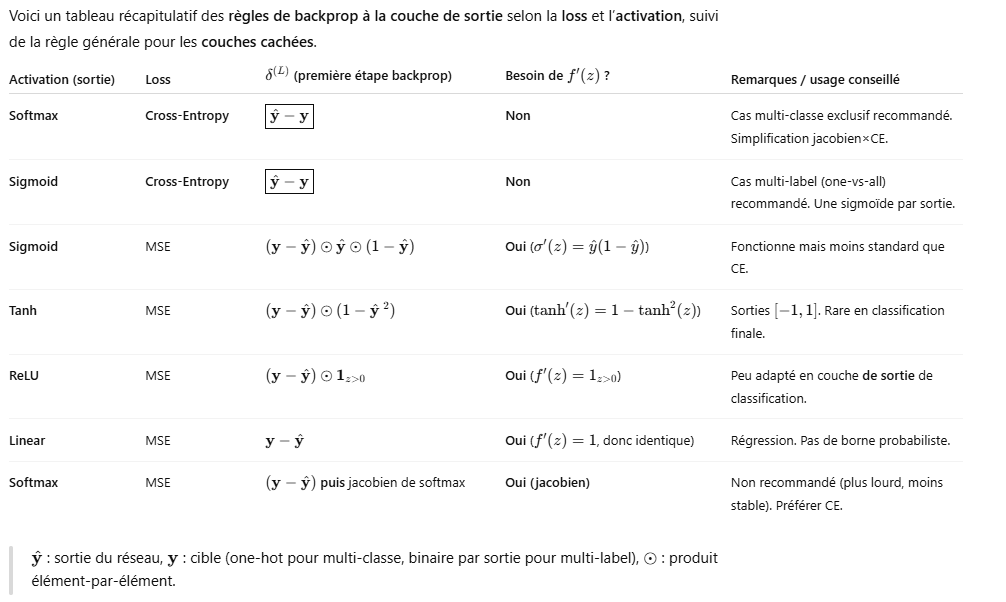

In [15]:

# Backpropagate error and store in neurons
# 'loss' in {'mse', 'cross_entropy'}
def backward_propagate_error(network, expected, activations=None, loss='mse'):
    n_layers = len(network)
    if activations is None:
        activations = ['sigmoid'] * n_layers
    assert len(activations) == n_layers, "len(activations) must equal number of layers"
    for i in reversed(range(n_layers)):
        layer = network[i]
        layer_act = (activations[i] or 'sigmoid').lower()
        if i == n_layers - 1:
            # couche de sortie
            if layer_act == 'softmax' and loss == 'cross_entropy':
                # delta = yhat - y
                for j in range(len(layer)):
                    yhat = layer[j]['output']
                    y = expected[j]
                    layer[j]['delta'] = (yhat - y)
            elif layer_act in ('sigmoid','logistic') and loss == 'cross_entropy':
                # delta = yhat - y
                for j in range(len(layer)):
                    yhat = layer[j]['output']
                    y = expected[j]
                    layer[j]['delta'] = (yhat - y)
            else:
                # fallback générique (ex: MSE)
                d_act = get_activation_derivative(layer_act)
                for j in range(len(layer)):
                    yhat = layer[j]['output']
                    y = expected[j]
                    error = y - yhat
                    layer[j]['delta'] = error * d_act(yhat)
        else:
            # couches cachées
            d_act = get_activation_derivative(layer_act)
            for j in range(len(layer)):
                error = 0.0
                for neuron in network[i + 1]:
                    error += (neuron['weights'][j] * neuron['delta'])
                layer[j]['delta'] = error * d_act(layer[j]['output'])


exemple de Calcul:

[texte du lien](https://)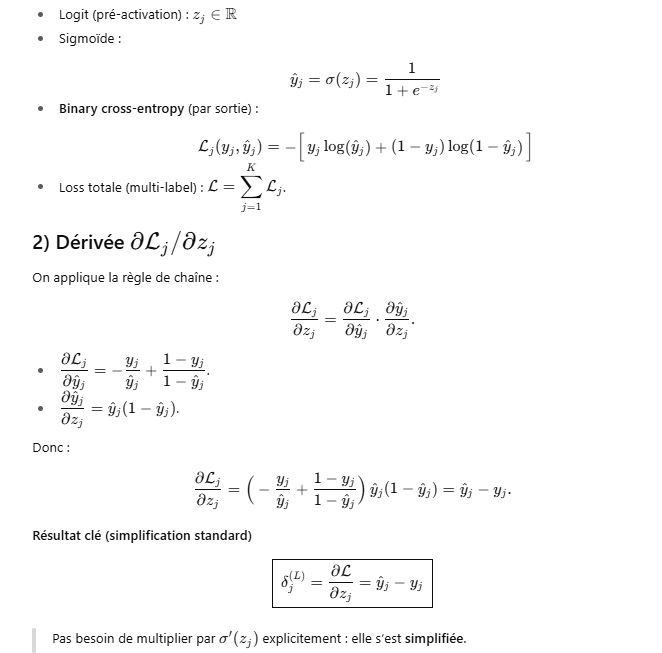

Exe. 9

In [16]:
# test backpropagation of error
expected = [0, 1]
print('######Before#########')
write(network)
backward_propagate_error(network, expected)
print('######After#########')
write(network)

######Before#########
layer : 1 

{'weights': [0.4, 0.7, 0.2], 'output': 0.6456563062257954} 

layer : 2 

{'weights': [0.9, 0.9], 'output': 0.8147372642938806} 

{'weights': [0.0, 0.0], 'output': 0.5} 

######After#########
layer : 1 

{'weights': [0.4, 0.7, 0.2], 'output': 0.6456563062257954, 'delta': -0.025321641068429778} 

layer : 2 

{'weights': [0.9, 0.9], 'output': 0.8147372642938806, 'delta': -0.12297681294192943} 

{'weights': [0.0, 0.0], 'output': 0.5, 'delta': 0.125} 



Exe. 10

In [17]:
# Update network weights with error
def update_weights(network, row, l_rate):
	for i in range(len(network)):
		inputs = row[:-1]
		if i != 0:
			inputs = [neuron['output'] for neuron in network[i - 1]]
		for neuron in network[i]:
			for j in range(len(inputs)):
				neuron['weights'][j] += l_rate * neuron['delta'] * inputs[j]
			neuron['weights'][-1] += l_rate * neuron['delta']

Exe. 11

In [18]:

# Loss cross-entropy (multi-classes one-hot), compatible sigmoid/softmax en sortie
def cross_entropy_loss(outputs, expected, eps=1e-12):
    loss = 0.0
    for yhat, y in zip(outputs, expected):
        yhat = min(max(yhat, eps), 1.0 - eps)  # clip
        loss += -(y * log(yhat) + (1.0 - y) * log(1.0 - yhat))
    return loss

# Train a network for a fixed number of epochs
def train_network(network, train, l_rate, n_epoch, n_outputs, activations=None, loss='mse'):
    for epoch in range(n_epoch):
        sum_error = 0.0
        for row in train:
            outputs = forward_propagate(network, row, activations=activations)
            expected = [0 for _ in range(n_outputs)]
            expected[row[-1]] = 1
            if loss == 'cross_entropy':
                sum_error += cross_entropy_loss(outputs, expected)
            else:
                sum_error += sum((expected[i] - outputs[i])**2 for i in range(len(expected)))
            backward_propagate_error(network, expected, activations=activations, loss=loss)
            update_weights(network, row, l_rate)
        tag = 'CE' if loss=='cross_entropy' else 'SSE'
        print('>epoch=%d, lrate=%.3f, %s=%.5f' % (epoch, l_rate, tag, sum_error))


Exe. 12

In [19]:
# Test training backprop algorithm
#seed(1)
dataset = [[2.7810836,2.550537003,0],
	[1.465489372,2.362125076,0],
	[3.396561688,4.400293529,0],
	[1.38807019,1.850220317,0],
	[3.06407232,3.005305973,0],
	[7.627531214,2.759262235,1],
	[5.332441248,2.088626775,1],
	[6.922596716,1.77106367,1],
	[8.675418651,-0.242068655,1],
	[7.673756466,3.508563011,1]]
n_inputs = len(dataset[0]) - 1
print(n_inputs)
n_outputs = len(set([row[-1] for row in dataset]))

print(n_outputs)
network = initialize_network(n_inputs, 2, n_outputs)
train_network(network, dataset, 0.5, 40, n_outputs)
#write(network)

2
2
>epoch=0, lrate=0.500, SSE=5.63722
>epoch=1, lrate=0.500, SSE=5.30598
>epoch=2, lrate=0.500, SSE=5.27781
>epoch=3, lrate=0.500, SSE=5.29331
>epoch=4, lrate=0.500, SSE=5.27446
>epoch=5, lrate=0.500, SSE=5.19810
>epoch=6, lrate=0.500, SSE=5.08069
>epoch=7, lrate=0.500, SSE=4.94497
>epoch=8, lrate=0.500, SSE=4.77706
>epoch=9, lrate=0.500, SSE=4.56121
>epoch=10, lrate=0.500, SSE=4.29848
>epoch=11, lrate=0.500, SSE=4.00253
>epoch=12, lrate=0.500, SSE=3.69051
>epoch=13, lrate=0.500, SSE=3.37805
>epoch=14, lrate=0.500, SSE=3.07732
>epoch=15, lrate=0.500, SSE=2.79622
>epoch=16, lrate=0.500, SSE=2.53869
>epoch=17, lrate=0.500, SSE=2.30586
>epoch=18, lrate=0.500, SSE=2.09715
>epoch=19, lrate=0.500, SSE=1.91110
>epoch=20, lrate=0.500, SSE=1.74584
>epoch=21, lrate=0.500, SSE=1.59935
>epoch=22, lrate=0.500, SSE=1.46963
>epoch=23, lrate=0.500, SSE=1.35474
>epoch=24, lrate=0.500, SSE=1.25287
>epoch=25, lrate=0.500, SSE=1.16238
>epoch=26, lrate=0.500, SSE=1.08180
>epoch=27, lrate=0.500, SSE=1.0098

Exe. 13

In [20]:
# Make a prediction with a network
def predict(network, row):
	outputs = forward_propagate(network, row)
	return outputs.index(max(outputs))

Exe. 14

In [21]:
# Test making predictions with the network
dataset = [[2.7810836,2.550537003,0],
	[1.465489372,2.362125076,0],
	[3.396561688,4.400293529,0],
	[1.38807019,1.850220317,0],
	[3.06407232,3.005305973,0],
	[7.627531214,2.759262235,1],
	[5.332441248,2.088626775,1],
	[6.922596716,1.77106367,1],
	[8.675418651,-0.242068655,1],
	[7.673756466,3.508563011,1]]
#network = [[{'weights': [-1.482313569067226, 1.8308790073202204, 1.078381922048799]}, {'weights': [0.23244990332399884, 0.3621998343835864, 0.40289821191094327]}],
#	[{'weights': [2.5001872433501404, 0.7887233511355132, -1.1026649757805829]}, {'weights': [-2.429350576245497, 0.8357651039198697, 1.0699217181280656]}]]
for row in dataset:
	prediction = predict(network, row)
	print('Expected=%d, Got=%d' % (row[-1], prediction))

Expected=0, Got=0
Expected=0, Got=0
Expected=0, Got=0
Expected=0, Got=0
Expected=0, Got=0
Expected=1, Got=1
Expected=1, Got=1
Expected=1, Got=1
Expected=1, Got=1
Expected=1, Got=1


**15. bis : More general case**


In [22]:

# Affichage des activations par couche
def describe_activations_for(network, activations=None):
    if activations is None:
        activations = ['sigmoid'] * len(network)
    print("Couches =", len(network))
    for i, act in enumerate(activations, 1):
        print(f"Couche {i}: activation = {act}")

In [24]:
# --- DATA-SET 1 (binaire) ---
dataset1 = [
    [2.7810836,2.550537003,0],
    [1.465489372,2.362125076,0],
    [3.396561688,4.400293529,0],
    [1.38807019,1.850220317,0],
    [3.06407232,3.005305973,0],
    [7.627531214,2.759262235,1],
    [5.332441248,2.088626775,1],
    [6.922596716,1.77106367,1],
    [8.675418651,-0.242068655,1],
    [7.673756466,3.508563011,1]
]
n_inputs, n_hidden, n_outputs = 2, 3, 2
configs = [
    (['tanh','sigmoid'],  'cross_entropy', 0.1, 60),  # recommandé (one-vs-all)
    (['tanh','sigmoid'],  'mse',           0.1, 60),  # comparaison
    (['relu','softmax'],  'cross_entropy', 0.1, 60),  # recommandé (multi-classe)
    (['relu','softmax'],  'mse',           0.1, 60),  # non recommandé, mais instructif
]

for activs, loss_name, lr, nepoch in configs:
    net = initialize_network(n_inputs, n_hidden, n_outputs)
    print(f"\n=== DATA-SET 1 | activations={activs} | loss={loss_name} ===")
    describe_activations_for(net, activs)
    train_network(net, dataset1, l_rate=lr, n_epoch=nepoch, n_outputs=n_outputs,
                  activations=activs, loss=loss_name)
    # accuracy sans fonction auxiliaire
    correct = 0
    for row in dataset1:
        outs = forward_propagate(net, row, activations=activs)
        pred = outs.index(max(outs))
        correct += (pred == row[-1])
    print(f"Accuracy: {correct/len(dataset1):.3f}")



=== DATA-SET 1 | activations=['tanh', 'sigmoid'] | loss=cross_entropy ===
Couches = 2
Couche 1: activation = tanh
Couche 2: activation = sigmoid
>epoch=0, lrate=0.100, CE=26.01057
>epoch=1, lrate=0.100, CE=41.21725
>epoch=2, lrate=0.100, CE=59.94402
>epoch=3, lrate=0.100, CE=79.69878
>epoch=4, lrate=0.100, CE=99.63739
>epoch=5, lrate=0.100, CE=119.60961
>epoch=6, lrate=0.100, CE=139.59161
>epoch=7, lrate=0.100, CE=159.57853
>epoch=8, lrate=0.100, CE=179.56869
>epoch=9, lrate=0.100, CE=199.56112
>epoch=10, lrate=0.100, CE=219.55523
>epoch=11, lrate=0.100, CE=239.55057
>epoch=12, lrate=0.100, CE=259.28683
>epoch=13, lrate=0.100, CE=272.35056
>epoch=14, lrate=0.100, CE=276.31043
>epoch=15, lrate=0.100, CE=276.31043
>epoch=16, lrate=0.100, CE=276.31043
>epoch=17, lrate=0.100, CE=276.31043
>epoch=18, lrate=0.100, CE=276.31043
>epoch=19, lrate=0.100, CE=276.31043
>epoch=20, lrate=0.100, CE=276.31043
>epoch=21, lrate=0.100, CE=276.31043
>epoch=22, lrate=0.100, CE=276.31043
>epoch=23, lrate=0

In [25]:
# --- DATA-SET 2 (multi-classe) ---
dataset2 = [
    # Classe 0
    [0.2, 0.1, 0],[0.1, 0.2, 0],[0.3, 0.2, 0],[0.2, 0.3, 0],
    # Classe 1
    [2.1, 2.0, 1],[2.2, 1.9, 1],[2.0, 2.2, 1],[2.3, 2.1, 1],
    # Classe 2
    [4.0, 0.2, 2],[4.2, 0.1, 2],[3.9, 0.3, 2],[4.1, 0.4, 2],
]
n_inputs, n_hidden, n_outputs = 2, 6, 3

configs_mc = [
    (['relu','softmax'], 'cross_entropy', 0.1, 120),  # recommandé si 'softmax' dispo
    (['tanh','sigmoid'], 'cross_entropy', 0.1, 120),  # one-vs-all (toujours compatible)
    (['relu','softmax'], 'mse',          0.1, 120),   # non recommandé (démo)
]

for activs, loss_name, lr, nepoch in configs_mc:
    print(f"\n=== DATA-SET 2 | activations={activs} | loss={loss_name} ===")
    net = initialize_network(n_inputs, n_hidden, n_outputs)
    describe_activations_for(net, activs)
    try:
        train_network(net, dataset2, l_rate=lr, n_epoch=nepoch, n_outputs=n_outputs,
                      activations=activs, loss=loss_name)
    except TypeError:
        print("⚠️ train_network ne supporte pas 'loss'/'activations' → fallback défaut")
        train_network(net, dataset2, l_rate=lr, n_epoch=nepoch, n_outputs=n_outputs)
    correct = 0
    for row in dataset2:
        try:
            outs = forward_propagate(net, row, activations=activs)
        except TypeError:
            outs = forward_propagate(net, row)
        pred = outs.index(max(outs))
        correct += (pred == row[-1])
    print(f"Accuracy: {correct/len(dataset2):.3f}")



=== DATA-SET 2 | activations=['relu', 'softmax'] | loss=cross_entropy ===
Couches = 2
Couche 1: activation = relu
Couche 2: activation = softmax
>epoch=0, lrate=0.100, CE=187.97215
>epoch=1, lrate=0.100, CE=442.09651
>epoch=2, lrate=0.100, CE=442.09651
>epoch=3, lrate=0.100, CE=442.09651
>epoch=4, lrate=0.100, CE=442.09651
>epoch=5, lrate=0.100, CE=442.09651
>epoch=6, lrate=0.100, CE=442.09651
>epoch=7, lrate=0.100, CE=442.09651
>epoch=8, lrate=0.100, CE=442.09651
>epoch=9, lrate=0.100, CE=442.09651
>epoch=10, lrate=0.100, CE=442.09651
>epoch=11, lrate=0.100, CE=442.09651
>epoch=12, lrate=0.100, CE=442.09651
>epoch=13, lrate=0.100, CE=442.09651
>epoch=14, lrate=0.100, CE=442.09651
>epoch=15, lrate=0.100, CE=442.09651
>epoch=16, lrate=0.100, CE=442.09651
>epoch=17, lrate=0.100, CE=442.09651
>epoch=18, lrate=0.100, CE=442.09651
>epoch=19, lrate=0.100, CE=442.09651
>epoch=20, lrate=0.100, CE=442.09651
>epoch=21, lrate=0.100, CE=442.09651
>epoch=22, lrate=0.100, CE=442.09651
>epoch=23, lr

In [26]:
# --- DATA-SET 3 (régression) ---
# y ≈ 3*x1 - 2*x2 + 0.5
dataset3 = []
for (x1,x2) in [(0,0),(1,0),(0,1),(2,1),(1,2),(2,2),(3,1),(1,3),(2,3),(3,3)]:
    y = 3*x1 - 2*x2 + 0.5
    dataset3.append([x1, x2, y])

n_inputs, n_hidden, n_outputs = 2, 5, 1
configs_reg = [
    (['relu','linear'], 0.05, 120),  # standard régression
    (['tanh','tanh'],   0.05, 120),  # sortie bornée
]

for activs, lr, nepoch in configs_reg:
    print(f"\n=== DATA-SET 3 | activations={activs} | loss=MSE ===")
    net = initialize_network(n_inputs, n_hidden, n_outputs)
    describe_activations_for(net, activs)
    for epoch in range(nepoch):
        sse = 0.0
        for row in dataset3:
            x = row[:-1]
            y = row[-1]
            # forward
            try:
                outs = forward_propagate(net, x, activations=activs)
            except TypeError:
                outs = forward_propagate(net, x)
            yhat = outs[0]
            sse += (y - yhat)**2
            # backprop (MSE)
            expected = [y]  # vecteur 1D pour la sortie
            try:
                backward_propagate_error(net, expected, activations=activs, loss='mse')
            except TypeError:
                backward_propagate_error(net, expected)
            # update (update_weights lit inputs depuis row[:-1])
            update_weights(net, x + [y], lr)
        if (epoch+1) % 30 == 0:
            print(f">epoch={epoch+1}, lrate={lr:.3f}, SSE={sse:.5f}")
    # prédictions
    print("Predictions (x1,x2) -> y_true ~ y_pred")
    for row in dataset3:
        x = row[:-1]; y = row[-1]
        try:
            yhat = forward_propagate(net, x, activations=activs)[0]
        except TypeError:
            yhat = forward_propagate(net, x)[0]
        print(f"{tuple(x)} -> {y:.2f} ~ {yhat:.2f}")



=== DATA-SET 3 | activations=['relu', 'linear'] | loss=MSE ===
Couches = 2
Couche 1: activation = relu
Couche 2: activation = linear
>epoch=30, lrate=0.050, SSE=0.78146
>epoch=60, lrate=0.050, SSE=0.31361
>epoch=90, lrate=0.050, SSE=0.36552
>epoch=120, lrate=0.050, SSE=0.31664
Predictions (x1,x2) -> y_true ~ y_pred
(0, 0) -> 0.50 ~ 0.69
(1, 0) -> 3.50 ~ 3.60
(0, 1) -> -1.50 ~ -1.40
(2, 1) -> 4.50 ~ 4.31
(1, 2) -> -0.50 ~ -0.78
(2, 2) -> 2.50 ~ 2.13
(3, 1) -> 7.50 ~ 7.08
(1, 3) -> -2.50 ~ -2.62
(2, 3) -> 0.50 ~ -0.06
(3, 3) -> 3.50 ~ 2.85

=== DATA-SET 3 | activations=['tanh', 'tanh'] | loss=MSE ===
Couches = 2
Couche 1: activation = tanh
Couche 2: activation = tanh
>epoch=30, lrate=0.050, SSE=90.38438
>epoch=60, lrate=0.050, SSE=73.53262
>epoch=90, lrate=0.050, SSE=72.00492
>epoch=120, lrate=0.050, SSE=71.94792
Predictions (x1,x2) -> y_true ~ y_pred
(0, 0) -> 0.50 ~ 0.53
(1, 0) -> 3.50 ~ 1.00
(0, 1) -> -1.50 ~ -0.96
(2, 1) -> 4.50 ~ 1.00
(1, 2) -> -0.50 ~ -0.72
(2, 2) -> 2.50 ~ 0.99
(

Exe. 15

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving seeds_dataset.csv to seeds_dataset.csv


In [ ]:
# Backprop on the Seeds Dataset
from random import seed
from random import randrange
from random import random
from csv import reader
from math import exp

Exe. 16

In [ ]:
from random import seed
from random import randrange
from random import random
from csv import reader
from math import exp
import pandas as pd

def load_csv(filename):
	dataset = list()
	with open(filename, 'r') as file:
		csv_reader = reader(file, delimiter=',')
		for row in csv_reader:
			if not row:
				continue
			dataset.append(row)
	return dataset

df = load_csv('seeds_dataset.csv')
dff = list()
for row in df:
    l = row[0].split('\t')
    row = [float(i) for i in l]
    row[-1] = int(row[-1] -1)
    dff.append(row)
dff

In [ ]:
# Test training backprop algorithm
#seed(1)
dataset = dff
n_inputs = len(dataset[0]) - 1
print(n_inputs)
n_outputs = len(set([row[-1] for row in dataset]))
print(n_outputs)
print(dff[0])

7
3
[15.26, 14.84, 0.871, 5.763, 3.312, 2.221, 5.22, 0]


In [ ]:
set([row[-1] for row in dataset])

{0, 1, 2}

In [ ]:

print(n_outputs)
network = initialize_network(n_inputs, 10, n_outputs)
#write(network)
train_network(network, dff, 0.05, 20, n_outputs)
#write(network)

In [ ]:

for row in dataset:
	prediction = predict(network, row)
	print('Expected=%d, Got=%d' % (row[-1], prediction))

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import pandas as pd
df=pd.read_csv('gdrive/My Drive/Colab Notebooks/NN_2021/seeds_dataset.csv',sep='\t+')
df

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  


,"""15.26",14.84,0.871,5.763,3.312,2.221,5.22,"1"""
0,"""14.88",14.57,0.8811,5.554,3.333,1.018,4.956,"1"""
1,"""14.29",14.09,0.9050,5.291,3.337,2.699,4.825,"1"""
2,"""13.84",13.94,0.8955,5.324,3.379,2.259,4.805,"1"""
3,"""16.14",14.99,0.9034,5.658,3.562,1.355,5.175,"1"""
4,"""14.38",14.21,0.8951,5.386,3.312,2.462,4.956,"1"""
...,...,...,...,...,...,...,...,...
204,"""12.19",13.20,0.8783,5.137,2.981,3.631,4.870,"3"""
205,"""11.23",12.88,0.8511,5.140,2.795,4.325,5.003,"3"""
206,"""13.2",13.66,0.8883,5.236,3.232,8.315,5.056,"3"""
207,"""11.84",13.21,0.8521,5.175,2.836,3.598,5.044,"3"""


In [ ]:
from random import random
from random import seed
seed(1)
# Initialize a network
nbr_hidden_neuron = [3,5,4]

def initialize_network_multiple_hidden(n_inputs, nbr_hidden_neuron, n_outputs):
# n_inputs = nbr d'inputs

# nbr_hidden_neuron = tableau de taille(n_hidden_layer) qui donne le nombre de neuronne par layer
# n_outputs = nombre d'outputs demandé
	network=list()
	for num_hidden in range(len(nbr_hidden_neuron)): # new! : this is where the number of layer is added
		nbre_nn = n_inputs if num_hidden == 0 else nbr_hidden_neuron[num_hidden - 1]
		print(nbre_nn)
		hidden_layer = [{'weights':[random() for i in range(nbre_nn + 1)]} for i in range(nbr_hidden_neuron[num_hidden])] # new! : add neurons based on nbr_hidden_neuro
		network.append(hidden_layer)
	output_layer = [{'weights':[random() for i in range(nbr_hidden_neuron[num_hidden]+1)]} for i in range(n_outputs)]
	network.append(output_layer)

	return network


In [ ]:
NN = initialize_network_multiple_hidden(n_inputs = 2, nbr_hidden_neuron = [2,4,5] , n_outputs = 2)
write(NN)

2
2
4
layer : 1 

{'weights': [0.13436424411240122, 0.8474337369372327, 0.763774618976614]} 

{'weights': [0.2550690257394217, 0.49543508709194095, 0.4494910647887381]} 

layer : 2 

{'weights': [0.651592972722763, 0.7887233511355132, 0.0938595867742349]} 

{'weights': [0.02834747652200631, 0.8357651039198697, 0.43276706790505337]} 

{'weights': [0.762280082457942, 0.0021060533511106927, 0.4453871940548014]} 

{'weights': [0.7215400323407826, 0.22876222127045265, 0.9452706955539223]} 

layer : 3 

{'weights': [0.9014274576114836, 0.030589983033553536, 0.0254458609934608, 0.5414124727934966, 0.9391491627785106]} 

{'weights': [0.38120423768821243, 0.21659939713061338, 0.4221165755827173, 0.029040787574867943, 0.22169166627303505]} 

{'weights': [0.43788759365057206, 0.49581224138185065, 0.23308445025757263, 0.2308665415409843, 0.2187810373376886]} 

{'weights': [0.4596034657377336, 0.28978161459048557, 0.021489705265908876, 0.8375779756625729, 0.5564543226524334]} 

{'weights': [0.64229

In [ ]:
# Backpropagate error and store in neurons
def backward_propagate_error(network, expected):
    for i in reversed(range(len(network))):
        layer = network[i]
        errors = list()
        if i != len(network)-1:
            for j in range(len(layer)):
                error = 0.0
                for neuron in network[i + 1]:
                    error += (neuron['weights'][j] * neuron['delta'])
                errors.append(error)
        else:
            for j in range(len(layer)):
                neuron = layer[j]
                errors.append(expected[j] - neuron['output'])
        for j in range(len(layer)):
            neuron = layer[j]
            if i != len(network)-1:
                    neuron['delta'] = errors[j] * transfer_derivative(neuron['output'])
            else:
                    neuron['delta'] = errors[j]